# Workshop 4: Branch analysis for readout physics

In dispersive readout, we often think in terms of bare-like states such as

(g, n), (e, n), ...

where the qubit state and resonator photon number remain approximately good labels.

But as the interaction becomes stronger, or as higher levels come into play, the true dressed eigenstates may no longer be cleanly connected to a single bare product state.

Branch analysis gives a systematic way to label dressed states and to track where that labeling becomes nontrivial.

In this notebook, we will:

1. build a transmon-resonator model
2. generate branch labels
3. inspect overlaps of selected dressed states
4. sweep a parameter and monitor when labels or state character change

In [138]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

## Step 1. Build a transmon + resonator system

We choose a slightly larger truncation so higher-state mixing is visible.

In [139]:
tmon = scq.Transmon(
    EJ=25.0,
    EC=1.0,
    ng=0.0,
    ncut=35,
    truncated_dim=5
)

res = scq.Oscillator(
    E_osc=6.0,
    truncated_dim=8
)

hilbertspace = scq.HilbertSpace([tmon, res])

g = 0.35
hilbertspace.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
)

## Step 2. Diagonalize and inspect the low-energy spectrum

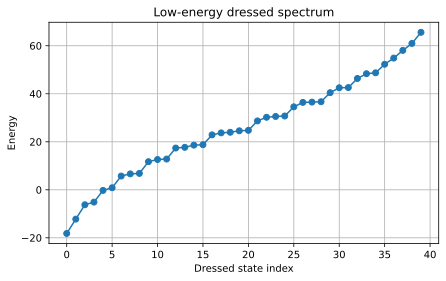

In [140]:
evals_count = 40
evals, evecs = hilbertspace.eigensys(evals_count=evals_count)

plt.figure(figsize=(7,4))
plt.plot(range(evals_count), evals, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Energy")
plt.title("Low-energy dressed spectrum")
plt.grid(True)
plt.show()

## Step 3. Generate branch-analysis labels

In [141]:
hilbertspace.generate_lookup(ordering="LX")
print("Generated LX lookup")
print([name for name in dir(hilbertspace) if "lookup" in name.lower() or "index" in name.lower()])

Generated LX lookup
['_generate_lookup_by_overlap', '_lookup_exists', 'bare_index', 'dressed_index', 'energy_by_bare_index', 'energy_by_dressed_index', 'generate_lookup', 'get_subsys_index', 'lookup_exists', 'set_npindextuple']


Depending on your scqubits version, the exact lookup accessors may differ.

Inspect:

- hilbertspace.lookup
- hilbertspace._lookup
- help(hilbertspace.generate_lookup)

In [142]:
for name in ["lookup", "_lookup"]:
    if hasattr(hilbertspace, name):
        print(f"\n{name}:")
        print(getattr(hilbertspace, name))

## Step 4. Inspect the bare-state content of dressed eigenstates

This is the most important diagnostic for understanding branch structure physically.

In [143]:
bare_labels = []
for t in range(tmon.truncated_dim):
    for r in range(res.truncated_dim):
        bare_labels.append((t, r))

overlap_table = np.abs(np.array([evecs[i].full().flatten() for i in range(len(evecs))]))**2

def print_top_components(dressed_index, top_n=40):
    probs = overlap_table[:, dressed_index]
    sorted_idx = np.argsort(probs)[::-1]
    print(f"Dressed state {dressed_index}, energy = {evals[dressed_index]:.6f}")
    for idx in sorted_idx[:top_n]:
        print(f"  bare {bare_labels[idx]}: {probs[idx]:.6f}")

In [144]:
# for i in range(evals_count):
#     print_top_components(i)
#     print()

print_top_components(25)
print()
print_top_components(26)
print()
print_top_components(27)
print()

Dressed state 25, energy = 34.558360
  bare (2, 2): 0.493591
  bare (2, 0): 0.481559
  bare (1, 6): 0.019840
  bare (3, 1): 0.002232
  bare (3, 2): 0.001891
  bare (0, 7): 0.000801
  bare (1, 3): 0.000068
  bare (2, 7): 0.000009
  bare (0, 5): 0.000007
  bare (0, 2): 0.000001
  bare (0, 0): 0.000000
  bare (2, 4): 0.000000
  bare (4, 0): 0.000000
  bare (0, 6): 0.000000
  bare (4, 2): 0.000000
  bare (3, 4): 0.000000
  bare (3, 6): 0.000000
  bare (1, 5): 0.000000
  bare (4, 5): 0.000000
  bare (4, 6): 0.000000
  bare (1, 4): 0.000000
  bare (0, 4): 0.000000
  bare (1, 0): 0.000000
  bare (1, 1): 0.000000
  bare (0, 3): 0.000000
  bare (1, 2): 0.000000
  bare (0, 1): 0.000000
  bare (4, 7): 0.000000
  bare (1, 7): 0.000000
  bare (2, 1): 0.000000
  bare (2, 5): 0.000000
  bare (2, 6): 0.000000
  bare (3, 0): 0.000000
  bare (3, 3): 0.000000
  bare (3, 5): 0.000000
  bare (3, 7): 0.000000
  bare (4, 1): 0.000000
  bare (4, 3): 0.000000
  bare (4, 4): 0.000000
  bare (2, 3): 0.000000

Dr

Interpretation:

- If one bare component dominates strongly, labeling is easy.
- If several components are comparable, the dressed state is strongly hybridized.
- Strong hybridization is where branch analysis becomes especially useful.

## Step 5. Quantify how mixed each dressed state is

For each dressed state, compute the largest bare-state probability.
If this quantity is close to 1, the state is nearly bare-like.
If it is smaller, the state is more strongly mixed.

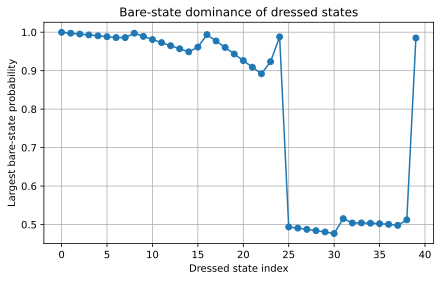

In [145]:
max_probs = []

for k in range(evals_count):
    probs = overlap_table[:, k]
    max_probs.append(np.max(probs))

plt.figure(figsize=(7,4))
plt.plot(range(evals_count), max_probs, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Largest bare-state probability")
plt.title("Bare-state dominance of dressed states")
plt.grid(True)
plt.show()

In [146]:
print("dressed_index\tenergy\tmax_prob\tdominant_bare_state")

for k in range(evals_count):
    probs = overlap_table[:, k]
    max_idx = np.argmax(probs)

    print(f"{k}\t{evals[k]:.6f}\t{probs[max_idx]:.6f}\t{bare_labels[max_idx]}")

dressed_index	energy	max_prob	dominant_bare_state
0	-18.194204	0.999724	(0, 0)
1	-12.213605	0.997451	(0, 1)
2	-6.233006	0.995182	(0, 2)
3	-5.129083	0.992915	(0, 4)
4	-0.252409	0.990650	(0, 6)
5	0.848733	0.988388	(1, 1)
6	5.728187	0.986163	(1, 5)
7	6.635439	0.986018	(2, 1)
8	6.826578	0.997431	(0, 3)
9	11.708783	0.989212	(0, 5)
10	12.615717	0.981057	(1, 0)
11	12.804450	0.972965	(1, 3)
12	17.390083	0.964936	(1, 7)
13	17.689585	0.956968	(2, 4)
14	18.595280	0.949007	(3, 0)
15	18.782350	0.961345	(3, 4)
16	22.880368	0.993803	(0, 7)
17	23.712075	0.977219	(1, 2)
18	23.962517	0.960395	(1, 6)
19	24.574177	0.943381	(2, 3)
20	24.760277	0.926229	(2, 7)
21	28.692115	0.908986	(3, 3)
22	30.213227	0.891842	(3, 6)
23	30.552457	0.923394	(4, 1)
24	30.738507	0.988022	(1, 4)
25	34.558360	0.493591	(2, 2)
26	36.410027	0.490704	(2, 6)
27	36.530171	0.487430	(3, 2)
28	36.685536	0.484030	(3, 7)
29	40.453416	0.480578	(4, 2)
30	42.506867	0.476694	(4, 4)
31	42.578559	0.515244	(4, 5)
32	46.367244	0.503964	(2, 0)
33	48

States with low maximum probability are good candidates for avoided crossings, strong hybridization, or branch ambiguity.

## Step 6. Sweep the coupling strength

Now we vary the coupling and track how mixed the low-energy dressed states become.
This shows where simple bare-state intuition starts to weaken.

In [147]:
g_values = np.linspace(0.05, 0.9, 18)
avg_maxprob = []
min_maxprob = []

for gval in g_values:
    hs = scq.HilbertSpace([tmon, res])

    hs.add_interaction(
        g_strength=gval,
        op1=tmon.n_operator,
        op2=res.creation_operator,
        add_hc=True
    )

    evals_tmp, evecs_tmp = hs.eigensys(evals_count=evals_count)

    overlaps_tmp = np.abs(
        np.array([evecs_tmp[i].full().flatten() for i in range(len(evecs_tmp))])
    )**2
    maxprob_list = [np.max(overlaps_tmp[:, k]) for k in range(evals_count)]

    avg_maxprob.append(np.mean(maxprob_list))
    min_maxprob.append(np.min(maxprob_list))


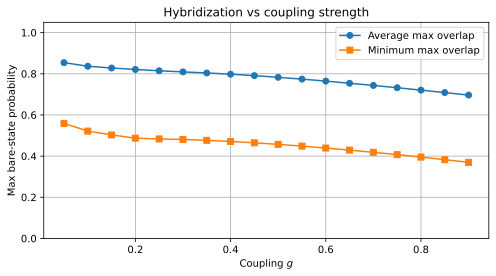

In [148]:
plt.figure(figsize=(7,4))

plt.plot(g_values, avg_maxprob, 'o-', label='Average max overlap')
plt.plot(g_values, min_maxprob, 's-', label='Minimum max overlap')

plt.xlabel("Coupling $g$")
plt.ylabel("Max bare-state probability")
plt.title("Hybridization vs coupling strength")

plt.ylim(0,1.05)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [149]:
print("g\tavg_maxprob\tmin_maxprob")
for g, avgp, minp in zip(g_values, avg_maxprob, min_maxprob):
    print(f"{g:.4f}\t{avgp:.6f}\t{minp:.6f}")

g	avg_maxprob	min_maxprob
0.0500	0.854110	0.558765
0.1000	0.836682	0.521499
0.1500	0.828101	0.502832
0.2000	0.821042	0.487202
0.2500	0.814594	0.483391
0.3000	0.809138	0.480855
0.3500	0.804004	0.476694
0.4000	0.798002	0.471214
0.4500	0.790983	0.464610
0.5000	0.782771	0.457016
0.5500	0.774157	0.448532
0.6000	0.764530	0.439235
0.6500	0.753903	0.429190
0.7000	0.743481	0.418455
0.7500	0.732258	0.407083
0.8000	0.720603	0.395126
0.8500	0.708716	0.382638
0.9000	0.696535	0.369673


Interpretation:

- average max overlap tells you the overall bare-like quality of the low-energy spectrum
- minimum max overlap tells you the most strongly mixed state in the inspected window

## Step 7. Compare DE and LX labeling

In [150]:
hs = scq.HilbertSpace([tmon, res])
hs.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
    )

hs.eigensys(evals_count=evals_count)

hs.generate_lookup(ordering="DE")
print("Generated DE lookup")
for name in ["lookup", "_lookup"]:
    if hasattr(hs, name):
        print(f"\n{name} under DE:")
        print(getattr(hs, name))

hs.generate_lookup(ordering="LX")
print("\nGenerated LX lookup")
for name in ["lookup", "_lookup"]:
    if hasattr(hs, name):
        print(f"\n{name} under LX:")
        print(getattr(hs, name))

Generated DE lookup

Generated LX lookup


In [152]:
hs.generate_lookup(ordering="DE")
de_labels = []
for j in range(evals_count):
    try:
        de_labels.append(hs.bare_index(j))
    except:
        de_labels.append(None)

hs.generate_lookup(ordering="LX")
lx_labels = []
for j in range(evals_count):
    try:
        lx_labels.append(hs.bare_index(j))
    except:
        lx_labels.append(None)

for j in range(evals_count):
    print(j, "DE:", de_labels[j], "LX:", lx_labels[j])

0 DE: (0, 0) LX: (0, 0)
1 DE: (0, 1) LX: (0, 1)
2 DE: (0, 2) LX: (0, 2)
3 DE: (1, 0) LX: (1, 0)
4 DE: (0, 3) LX: (0, 3)
5 DE: (1, 1) LX: (1, 1)
6 DE: (0, 4) LX: (0, 4)
7 DE: (1, 2) LX: (1, 2)
8 DE: (2, 0) LX: (2, 0)
9 DE: (0, 5) LX: (0, 5)
10 DE: (1, 3) LX: (1, 3)
11 DE: (2, 1) LX: (2, 1)
12 DE: (0, 6) LX: (0, 6)
13 DE: (3, 0) LX: (3, 0)
14 DE: (1, 4) LX: (1, 4)
15 DE: (2, 2) LX: (2, 2)
16 DE: (4, 0) LX: (4, 0)
17 DE: (0, 7) LX: (0, 7)
18 DE: (1, 5) LX: (1, 5)
19 DE: (2, 3) LX: (2, 3)
20 DE: None LX: (3, 1)
21 DE: (4, 1) LX: (4, 1)
22 DE: (1, 6) LX: (1, 6)
23 DE: (2, 4) LX: (2, 4)
24 DE: None LX: (3, 2)
25 DE: None LX: (4, 2)
26 DE: (1, 7) LX: (1, 7)
27 DE: None LX: (2, 5)
28 DE: None LX: (3, 3)
29 DE: None LX: (4, 3)
30 DE: None LX: (2, 6)
31 DE: None LX: (3, 4)
32 DE: None LX: (4, 4)
33 DE: (2, 7) LX: (2, 7)
34 DE: None LX: (3, 5)
35 DE: None LX: (4, 5)
36 DE: (3, 7) LX: (4, 6)
37 DE: None LX: (3, 6)
38 DE: None LX: (3, 7)
39 DE: (4, 7) LX: (4, 7)


In [153]:
states_to_inspect = [20, 24, 25, 27, 28, 29]   # DE=None indices you saw

for k in states_to_inspect:
    vec = evecs[k].full().flatten()

    print(f"\nDressed state {k}, energy = {evals[k]:.6f}")
    
    for i, amp in enumerate(vec):
        prob = np.abs(amp)**2
        if prob > 1e-4:   # only print meaningful components
            print(f"  bare {bare_labels[i]} : amplitude = {amp:.4f}, prob = {prob:.6f}")


Dressed state 20, energy = 24.760277
  bare (0, 4) : amplitude = -0.0362+0.0000j, prob = 0.001310
  bare (0, 6) : amplitude = -0.1088+0.0000j, prob = 0.011830
  bare (1, 5) : amplitude = 0.9782+0.0000j, prob = 0.956968
  bare (2, 4) : amplitude = -0.1615+0.0000j, prob = 0.026075
  bare (2, 6) : amplitude = -0.0577+0.0000j, prob = 0.003325
  bare (3, 3) : amplitude = 0.0150+0.0000j, prob = 0.000225
  bare (3, 5) : amplitude = 0.0108+0.0000j, prob = 0.000117

Dressed state 24, energy = 30.738507
  bare (0, 5) : amplitude = -0.0395+0.0000j, prob = 0.001557
  bare (0, 7) : amplitude = -0.1176+0.0000j, prob = 0.013838
  bare (1, 4) : amplitude = -0.0117+0.0000j, prob = 0.000138
  bare (1, 6) : amplitude = 0.9742+0.0000j, prob = 0.949007
  bare (2, 5) : amplitude = -0.1762+0.0000j, prob = 0.031045
  bare (2, 7) : amplitude = -0.0621+0.0000j, prob = 0.003854
  bare (3, 4) : amplitude = 0.0183+0.0000j, prob = 0.000335
  bare (3, 6) : amplitude = 0.0128+0.0000j, prob = 0.000165

Dressed state 

You are checking whether the local overlap-based assignment and the recursive branch-based assignment remain consistent.

If they differ, that is usually a sign that naive dressed-state labeling is becoming unreliable.

In [154]:
bare_state = (4,2)
vec = hilbertspace.bare_productstate(bare_state)

for k in range(evals_count):
    overlap = abs(vec.overlap(evecs[k]))**2
    if overlap > 0.1:
        print(k, overlap)

25 0.5034096154296153
26 0.49096149346518064


## Exercises

1. Change the resonator frequency from 6.0 to 5.0 and repeat the notebook.
   Does the amount of mixing increase or decrease?

2. Increase the transmon truncation from 5 to 7.
   Which dressed states change most?

3. For one strongly mixed dressed state, print its top 10 bare components and describe the pattern.

4. Compare:
   - weak coupling g = 0.1
   - intermediate coupling g = 0.4
   - strong coupling g = 0.8

   For each case, identify whether DE and LX appear to agree.

5. Reverse subsystem order:
   `HilbertSpace([res, tmon])`
   Then use:
   `generate_lookup(ordering="LX", subsys_priority=[1,0])`
   Verify that the branch logic is restored.

# Takeaway

By the end of this notebook, you should understand:
1. branch analysis is not just a software trick,
2. it is a way to preserve meaningful state identity in an interacting system,
3. when state mixing grows, naive labeling becomes fragile,
4. that fragility is directly related to the breakdown of simple readout intuition.
